In [71]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [72]:
import pandas as pd
import numpy as np
import os
import joblib

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

from sklearn.metrics import classification_report

In [73]:
system_features = pd.read_csv(
    "/content/drive/MyDrive/Cloud anomaly detection/processed dataset/system_features.csv"
)

In [74]:
print(system_features.shape)

system_features.head()

(405894, 14)


,avg_cpu,avg_memory,max_cpu,max_memory,sample_cpu,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,vertical_scaling,scheduler,priority,scheduling_class,failed
0,0.004662,5.920410e-03,0.011902,5.935669e-03,0.004349,0.014435,0.000415,1.918681,0.009506,1.0,0.0,200,3,1
1,0.000000,9.536743e-07,0.000000,9.536743e-07,0.000000,0.000000,0.000000,1.918681,0.009506,2.0,0.0,360,2,1
2,0.024200,2.788544e-03,0.060059,2.845764e-03,0.026459,0.010422,0.000235,0.939919,0.001318,2.0,1.0,103,2,0
3,0.047607,3.442383e-02,0.133301,3.466797e-02,0.050842,0.041626,0.000225,1.359102,0.007643,2.0,0.0,200,3,1
4,0.000271,7.629395e-05,0.000415,7.629395e-05,0.000341,0.000272,0.000010,1.918681,0.009506,3.0,0.0,0,2,0


In [75]:
system_features.isnull().sum()

,0
avg_cpu,0
avg_memory,0
max_cpu,0
max_memory,0
sample_cpu,0
assigned_memory,0
page_cache_memory,0
cycles_per_instruction,0
memory_accesses_per_instruction,0
vertical_scaling,0


In [76]:
system_features.columns.tolist()

['avg_cpu',
 'avg_memory',
 'max_cpu',
 'max_memory',
 'sample_cpu',
 'assigned_memory',
 'page_cache_memory',
 'cycles_per_instruction',
 'memory_accesses_per_instruction',
 'vertical_scaling',
 'scheduler',
 'priority',
 'scheduling_class',
 'failed']

In [77]:
X_system = system_features.copy()

print(X_system.shape)

(405894, 14)


In [78]:
iso_system = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

In [79]:
system_features['if_prediction'] = iso_system.fit_predict(X_system)

In [80]:
system_features['if_prediction'].value_counts()

,count
if_prediction,
1,385610
-1,20284


In [81]:
system_features['if_prediction'].value_counts(normalize=True)

,proportion
if_prediction,
1,0.950026
-1,0.049974


In [82]:
system_features['if_score'] = iso_system.decision_function(X_system)

In [83]:
system_features[['if_prediction',
                 'if_score']].head()

,if_prediction,if_score
0,1,0.090968
1,1,0.140235
2,1,0.087398
3,-1,-0.053858
4,1,0.172582


In [84]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    novelty=True,
    n_jobs=-1
)

In [85]:
lof.fit(X_system)

system_features['lof_prediction'] = lof.predict(X_system)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


In [86]:
# ==========================================
# SAVE SYSTEM MODELS
# ==========================================

models_path = "/content/drive/MyDrive/Cloud anomaly detection/models"

os.makedirs(models_path, exist_ok=True)

joblib.dump(
    iso_system,
    f"{models_path}/system_if.pkl"
)

joblib.dump(
    lof,
    f"{models_path}/system_lof.pkl"
)

print("Models Saved Successfully")
print("1. system_if.pkl")
print("2. system_lof.pkl")

Models Saved Successfully
1. system_if.pkl
2. system_lof.pkl


In [87]:
import os

models_path = "/content/drive/MyDrive/Cloud anomaly detection/models"

print(os.listdir(models_path))

['auth', 'system', 'system_if.pkl', 'system_lof.pkl']


In [88]:
loaded_if = joblib.load(
    "/content/drive/MyDrive/Cloud anomaly detection/models/system_if.pkl"
)

loaded_lof = joblib.load(
    "/content/drive/MyDrive/Cloud anomaly detection/models/system_lof.pkl"
)

print(type(loaded_if))
print(type(loaded_lof))

<class 'sklearn.ensemble._iforest.IsolationForest'>
<class 'sklearn.neighbors._lof.LocalOutlierFactor'>


In [89]:
system_features['lof_prediction'].value_counts()

,count
lof_prediction,
1,394834
-1,11060


In [90]:
system_features['lof_score'] = lof.negative_outlier_factor_

In [91]:
system_features[
    ['if_prediction',
     'if_score',
     'lof_prediction',
     'lof_score']
].head()

,if_prediction,if_score,lof_prediction,lof_score
0,1,0.090968,1,-1.0
1,1,0.140235,1,-1.0
2,1,0.087398,1,-1.0
3,-1,-0.053858,1,-1.0
4,1,0.172582,1,-1.0


In [92]:
system_features['final_anomaly'] = (
    (system_features['if_prediction'] == -1)
    |
    (system_features['lof_prediction'] == -1)
).astype(int)

In [93]:
system_features['final_anomaly'].value_counts()

,count
final_anomaly,
0,375187
1,30707


In [94]:
from sklearn.preprocessing import MinMaxScaler

In [95]:
score_scaler = MinMaxScaler()

In [96]:
system_features['if_score_scaled'] = score_scaler.fit_transform(
    system_features[['if_score']]
)

In [97]:
system_features['lof_score_inverted'] = (
    -system_features['lof_score']
)

In [98]:
system_features['lof_score_scaled'] = score_scaler.fit_transform(
    system_features[['lof_score_inverted']]
)

In [99]:
system_features['risk_score'] = (
    (1 - system_features['if_score_scaled'])
    +
    system_features['lof_score_scaled']
) / 2

In [100]:
system_features[
    ['risk_score']
].describe()

,risk_score
count,4.058940e+05
mean,9.623268e-02
std,7.682320e-02
min,3.391845e-14
25%,4.225991e-02
50%,7.620274e-02
75%,1.222806e-01
max,8.239112e-01


In [101]:
top_system_anomalies = (
    system_features
    .sort_values(
        'risk_score',
        ascending=False
    )
    .head(100)
)

In [102]:
top_system_anomalies.head()

,avg_cpu,avg_memory,max_cpu,max_memory,sample_cpu,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,vertical_scaling,...,failed,if_prediction,if_score,lof_prediction,lof_score,final_anomaly,if_score_scaled,lof_score_inverted,lof_score_scaled,risk_score
238784,0.032166,0.00084,0.609375,0.000848,0.026245,0.001577,0.000011,105.275932,0.003779,3.0,...,0,-1,-0.060489,-1,-8.649070e+11,1,0.352178,8.649070e+11,1.000000e+00,0.823911
170908,0.527344,0.22168,1.271484,0.222168,0.644531,0.264648,0.001070,1.918681,0.009506,1.0,...,0,-1,-0.195956,1,-1.000000e+00,1,0.000000,1.000000e+00,6.783691e-14,0.500000
291932,0.527344,0.22168,1.271484,0.222168,0.644531,0.264648,0.001070,1.918681,0.009506,1.0,...,0,-1,-0.195956,1,-1.000000e+00,1,0.000000,1.000000e+00,6.783691e-14,0.500000
100440,0.527344,0.22168,1.271484,0.222168,0.644531,0.264648,0.001070,1.918681,0.009506,1.0,...,0,-1,-0.195956,1,-1.000000e+00,1,0.000000,1.000000e+00,6.783691e-14,0.500000
182404,0.527344,0.22168,1.271484,0.222168,0.644531,0.264648,0.001070,1.918681,0.009506,1.0,...,0,-1,-0.195956,1,-1.000000e+00,1,0.000000,1.000000e+00,6.783691e-14,0.500000


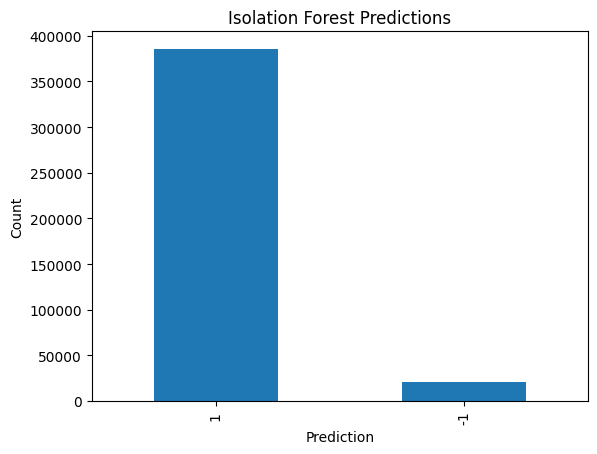

In [103]:
import matplotlib.pyplot as plt

system_features['if_prediction'].value_counts().plot(
    kind='bar'
)

plt.title("Isolation Forest Predictions")
plt.xlabel("Prediction")
plt.ylabel("Count")
plt.show()

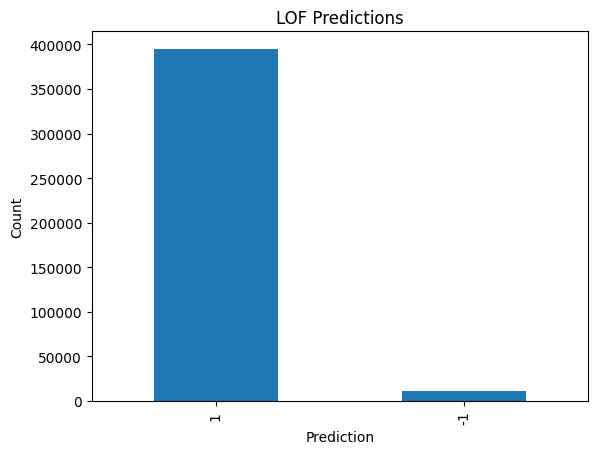

In [104]:
system_features['lof_prediction'].value_counts().plot(
    kind='bar'
)

plt.title("LOF Predictions")
plt.xlabel("Prediction")
plt.ylabel("Count")
plt.show()

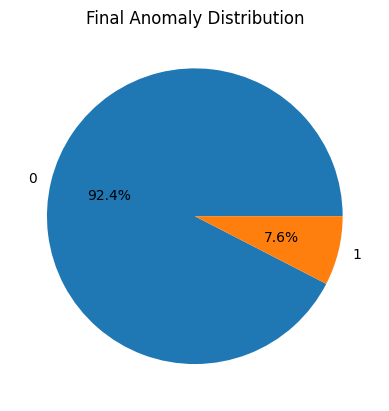

In [105]:
system_features['final_anomaly'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Final Anomaly Distribution")
plt.ylabel("")
plt.show()

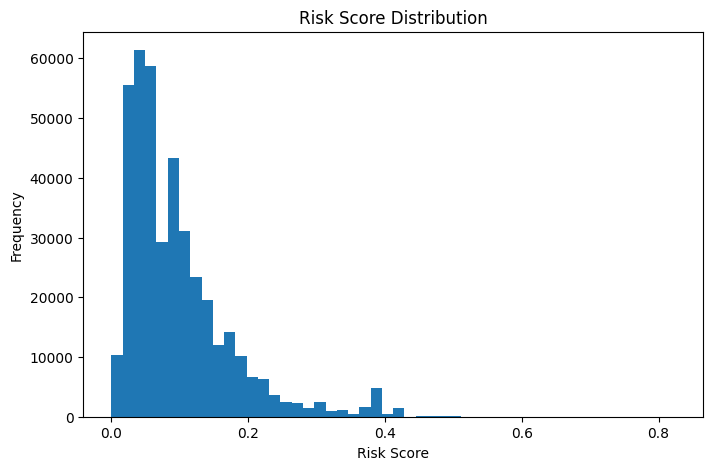

In [106]:
plt.figure(figsize=(8,5))

plt.hist(
    system_features['risk_score'],
    bins=50
)

plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")

plt.show()

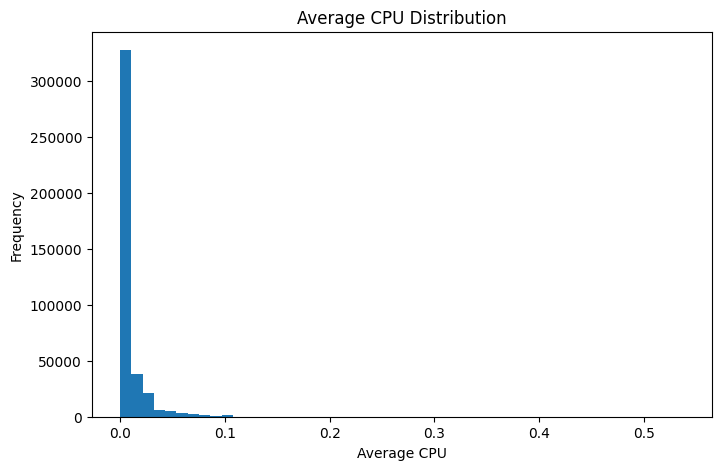

In [107]:
plt.figure(figsize=(8,5))

plt.hist(
    system_features['avg_cpu'],
    bins=50
)

plt.title("Average CPU Distribution")
plt.xlabel("Average CPU")
plt.ylabel("Frequency")

plt.show()

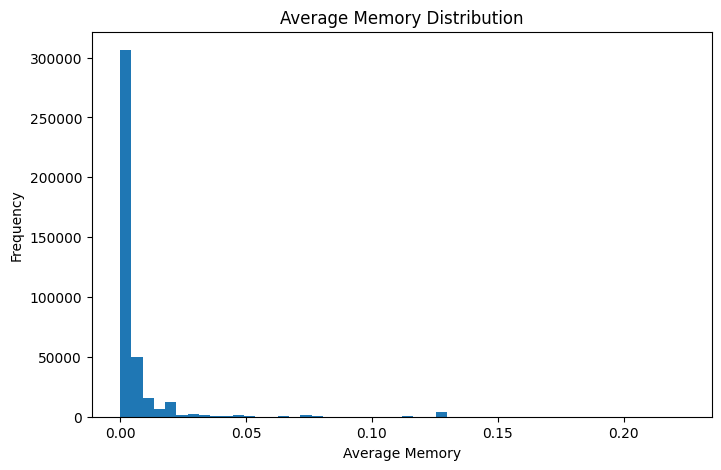

In [108]:
plt.figure(figsize=(8,5))

plt.hist(
    system_features['avg_memory'],
    bins=50
)

plt.title("Average Memory Distribution")
plt.xlabel("Average Memory")
plt.ylabel("Frequency")

plt.show()

In [109]:
top20 = (
    system_features
    .sort_values(
        'risk_score',
        ascending=False
    )
    .head(20)
)

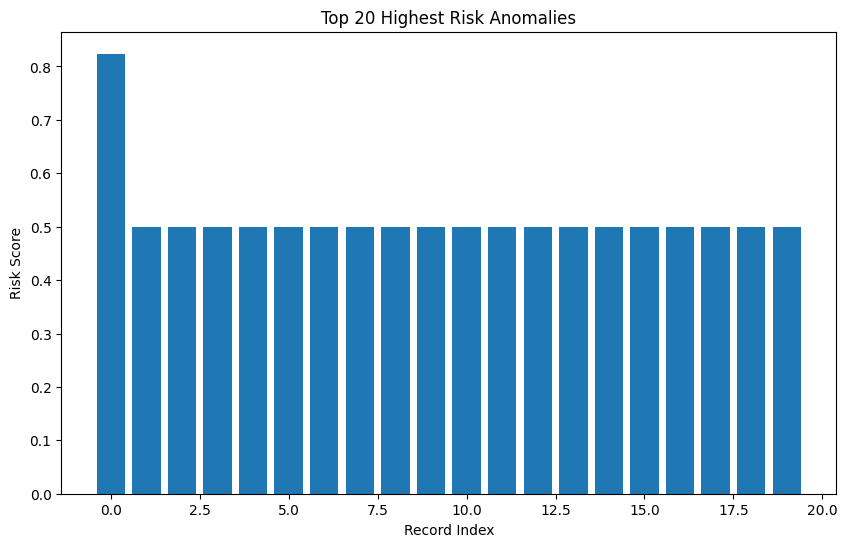

In [110]:
plt.figure(figsize=(10,6))

plt.bar(
    range(len(top20)),
    top20['risk_score']
)

plt.title("Top 20 Highest Risk Anomalies")
plt.xlabel("Record Index")
plt.ylabel("Risk Score")

plt.show()

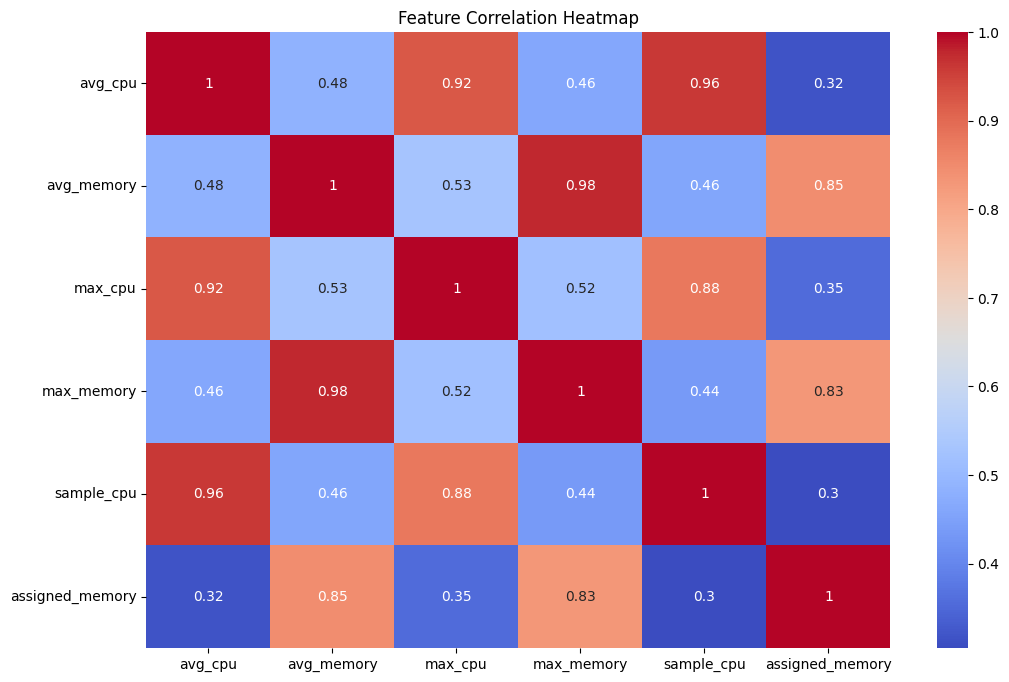

In [111]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    system_features[
        [
            'avg_cpu',
            'avg_memory',
            'max_cpu',
            'max_memory',
            'sample_cpu',
            'assigned_memory'
        ]
    ].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [112]:
import os

results_path = "/content/drive/MyDrive/Cloud anomaly detection/results"

os.makedirs(results_path, exist_ok=True)

print("Results folder created")

Results folder created


In [113]:
system_features.to_csv(
    "/content/drive/MyDrive/Cloud anomaly detection/results/system_anomalies.csv",
    index=False
)

print("system_anomalies.csv saved")

system_anomalies.csv saved


In [114]:
top_system_anomalies.to_csv(
    "/content/drive/MyDrive/Cloud anomaly detection/results/top_system_anomalies.csv",
    index=False
)

print("top_system_anomalies.csv saved")

top_system_anomalies.csv saved


In [115]:
import os

os.listdir("/content/drive/MyDrive/Cloud anomaly detection/results")

['API',
 'system',
 'auth',
 'CORRELATION_ENGINE',
 'system_anomalies.csv',
 'top_system_anomalies.csv']

In [116]:
print("="*50)
print("SYSTEM ANOMALY DETECTION COMPLETED")
print("="*50)

print("Total records:", len(system_features))
print("Detected anomalies:", system_features['final_anomaly'].sum())

print(
    "Anomaly percentage:",
    round(
        system_features['final_anomaly'].mean()*100,
        2
    ),
    "%"
)

print("\nFiles Saved:")
print("1. system_anomalies.csv")
print("2. top_system_anomalies.csv")

SYSTEM ANOMALY DETECTION COMPLETED
Total records: 405894
Detected anomalies: 30707
Anomaly percentage: 7.57 %

Files Saved:
1. system_anomalies.csv
2. top_system_anomalies.csv


In [117]:
import os

results_dir = "/content/drive/MyDrive/Cloud anomaly detection/results/SYSTEM_ANOMALITY"

os.makedirs(results_dir, exist_ok=True)

print("Folder ready:", results_dir)

Folder ready: /content/drive/MyDrive/Cloud anomaly detection/results/SYSTEM_ANOMALITY


In [118]:
summary_text = f"""
==================================================
SYSTEM ANOMALY DETECTION RESULTS
==================================================

Total Records: {len(system_features)}

Isolation Forest Anomalies:
{(system_features['if_prediction'] == -1).sum()}

LOF Anomalies:
{(system_features['lof_prediction'] == -1).sum()}

Final Ensemble Anomalies:
{system_features['final_anomaly'].sum()}

Anomaly Percentage:
{round(system_features['final_anomaly'].mean()*100, 2)} %

Files Generated:
1. system_anomalies.csv
2. top_system_anomalies.csv

==================================================
"""

with open(
    f"{results_dir}/system_results_summary.txt",
    "w"
) as f:
    f.write(summary_text)

print("Summary saved")

Summary saved


In [119]:
plt.savefig(
    f"{results_dir}/isolation_forest_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

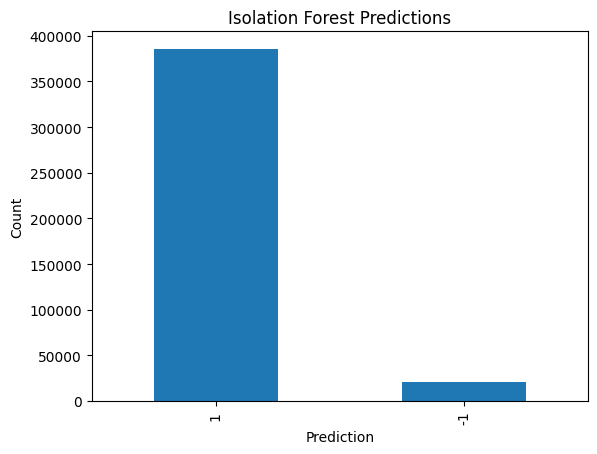

In [120]:
system_features['if_prediction'].value_counts().plot(
    kind='bar'
)

plt.title("Isolation Forest Predictions")
plt.xlabel("Prediction")
plt.ylabel("Count")

plt.savefig(
    f"{results_dir}/isolation_forest_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [121]:
plt.savefig(
    f"{results_dir}/lof_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [122]:
plt.savefig(
    f"{results_dir}/final_anomaly_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [123]:
plt.savefig(
    f"{results_dir}/risk_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [124]:
plt.savefig(
    f"{results_dir}/avg_cpu_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [125]:
plt.savefig(
    f"{results_dir}/avg_memory_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [126]:
plt.savefig(
    f"{results_dir}/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [127]:
plt.savefig(
    f"{results_dir}/top20_highest_risk_anomalies.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [128]:
system_features.to_csv(
    f"{results_dir}/system_anomalies.csv",
    index=False
)

top_system_anomalies.to_csv(
    f"{results_dir}/top_system_anomalies.csv",
    index=False
)

print("CSV files saved")

CSV files saved


In [129]:
import os

files = os.listdir(results_dir)

print("Files saved:\n")

for file in files:
    print(file)

Files saved:

system_results_summary.txt
isolation_forest_predictions.png
lof_predictions.png
final_anomaly_distribution.png
risk_score_distribution.png
avg_cpu_distribution.png
avg_memory_distribution.png
correlation_heatmap.png
top20_highest_risk_anomalies.png
system_anomalies.csv
top_system_anomalies.csv
